In [1]:
from pathlib import Path
import sys
import os

PROJECT_ROOT = Path.cwd().parent

import pandas as pd

import json
from src import constants as Con

from predictive_modeling.answer_correctness.model_data import (
    load_all_features,
)

from src.data_paths import (
    HUNTERS_PROCESSED_PATH,
    GATHERERS_PROCESSED_PATH,

    IA_QA_PATH,
    FIX_QA_PATH,
)

In [3]:
ia = pd.read_csv(IA_QA_PATH)
fix = pd.read_csv(FIX_QA_PATH)

C:\Users\deeth\AppData\Local\Temp\ipykernel_10244\1430756291.py:2: DtypeWarning: Columns (0: CURRENT_FIX_PRECISION_MEASURE_RMS_S2S, 1: CURRENT_FIX_PRECISION_MEASURE_SD_WINDOW, 2: universal_pos, 3: ptb_pos, 4: dependency_relation, 5: morphological_features, 6: entity_type) have mixed types. Specify dtype option on import or set low_memory=False.
  fix = pd.read_csv(FIX_QA_PATH)


In [2]:
from pathlib import Path

def save_participant_trial_rows(
    participant_id,
    trial_index,
    save_location,
    ia_df,
    fx_df,
    name
):
    """
    Save all rows for one participant-trial pair from IA and fixation dataframes.

    Creates:
    - [name]_ia.csv
    - [name]_fix.csv
    """

    save_path = Path(save_location)
    save_path.mkdir(parents=True, exist_ok=True)

    ia_subset = ia_df[
        (ia_df['participant_id'] == participant_id) &
        (ia_df['TRIAL_INDEX'] == trial_index)
    ].copy()

    fx_subset = fx_df[
        (fx_df['participant_id'] == participant_id) &
        (fx_df['TRIAL_INDEX'] == trial_index)
    ].copy()

    ia_file = save_path / f"{name}_ia.csv"
    fx_file = save_path / f"{name}_fix.csv"

    ia_subset.to_csv(ia_file, index=False, encoding='utf-8-sig')
    fx_subset.to_csv(fx_file, index=False, encoding='utf-8-sig')

    print(f"Saved IA rows: {len(ia_subset)} → {ia_file}")
    print(f"Saved fixation rows: {len(fx_subset)} → {fx_file}")

    return ia_subset, fx_subset

In [2]:
SAVE_PATH = PROJECT_ROOT.parent.parent / "scanpath examples" / "scanpath studio data"

In [3]:
hunters = pd.read_csv(HUNTERS_PROCESSED_PATH)
gatherers = pd.read_csv(GATHERERS_PROCESSED_PATH)
all_participants = pd.concat([hunters, gatherers], ignore_index=True)


In [4]:
trial_df = load_all_features()

In [5]:
trial_df

,participant_id,TRIAL_INDEX,text_id_with_q,is_correct,area_dwell_proportion__answer_A,area_dwell_proportion__answer_B,area_dwell_proportion__answer_C,area_dwell_proportion__answer_D,area_dwell_proportion__question,first_encounter_avg_pupil_size_z__answer_A,...,TimeSinceOffset_pure_distance_furthest,TimeSinceOffset_pure_distance_closest,TimeSinceOffset_normalized_correct,TimeSinceOffset_normalized_wrong_mean,TimeSinceOffset_normalized_contrast,TimeSinceOffset_normalized_distance_furthest,TimeSinceOffset_normalized_distance_closest,ANSWER_PRESS_NUMBER,total_answering_RT,total_answering_RT_normalized
0,l42_2070,4,3_6_Ele_1_2,1,0.319310,0.213167,0.181306,0.257173,0.029044,0.798335,...,1734.0,251.0,593.000000,602.857143,-9.857143,163.000000,48.857143,1,7330,222.121212
1,l42_2070,5,3_6_Adv_2_2,1,0.244538,0.469212,0.170161,0.116089,0.000000,0.086368,...,1110.0,23.0,106.083333,261.925926,-155.842593,158.694444,153.116667,1,5650,141.250000
2,l42_2070,6,3_6_Ele_3_0,1,0.388110,0.148282,0.349458,0.079114,0.035036,-0.436190,...,2750.0,1584.0,324.500000,277.523810,46.976190,269.500000,179.928571,1,5562,135.658537
3,l42_2070,7,3_6_Adv_4_1,1,0.501591,0.178867,0.126353,0.147995,0.045194,0.590876,...,3599.0,1576.0,404.900000,219.950000,184.950000,359.900000,89.700000,1,4762,136.057143
4,l42_2070,8,3_6_Ele_5_0,1,0.241206,0.370537,0.153399,0.177466,0.057392,-1.167965,...,1748.0,287.0,123.000000,211.171296,-88.171296,264.625000,59.222222,1,4884,103.914894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19431,l2_324,61,3_6_Ele_7_2,1,0.294371,0.236904,0.185692,0.213448,0.069586,-0.461954,...,2544.0,1712.0,442.857143,113.013889,329.843254,369.982143,269.357143,4,3353,83.825000
19432,l2_324,62,3_9_Adv_1_2,1,0.429921,0.044094,0.087402,0.346457,0.092126,0.812895,...,1204.0,780.0,180.000000,40.833333,139.166667,172.000000,84.000000,1,1898,59.312500
19433,l2_324,63,3_9_Adv_2_1,0,0.170213,0.143830,0.327234,0.288936,0.069787,0.073022,...,453.0,22.0,100.000000,97.722222,2.277778,46.000000,3.000000,3,2937,104.892857
19434,l2_324,64,3_9_Adv_3_0,1,0.301277,0.249061,0.200977,0.193464,0.055222,0.870679,...,379.0,197.0,79.666667,62.500000,17.166667,21.966667,10.666667,4,3460,59.655172


In [30]:
df_acc = (
    all_participants[['participant_id', 'TRIAL_INDEX', 'is_correct']]
    .drop_duplicates(subset=['participant_id', 'TRIAL_INDEX'])
    .copy()
)

n_correct = df_acc['is_correct'].eq(1).sum()
n_total = df_acc['is_correct'].notna().sum()
percent_correct = n_correct / n_total * 100

print(f"Correct participant-trial pairs: {n_correct} / {n_total}")
print(f"Percent correct: {percent_correct:.2f}%")

Correct participant-trial pairs: 16339 / 19436
Percent correct: 84.07%


,selected_answer_label,n_selected,percent_selected
0,A,16339,84.065651
1,B,1744,8.973040
2,C,942,4.846676
3,D,411,2.114633


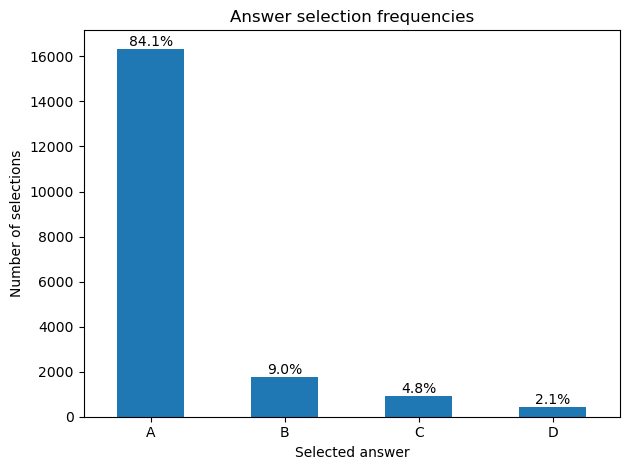

In [31]:
import matplotlib.pyplot as plt

df_answers = (
    all_participants[['participant_id', 'TRIAL_INDEX', 'selected_answer_label']]
    .drop_duplicates(subset=['participant_id', 'TRIAL_INDEX'])
    .copy()
)

answer_counts = (
    df_answers['selected_answer_label']
    .value_counts(dropna=False)
    .reset_index()
)

answer_counts.columns = ['selected_answer_label', 'n_selected']

answer_counts['percent_selected'] = (
    answer_counts['n_selected'] / answer_counts['n_selected'].sum() * 100
)

display(answer_counts)

ax = answer_counts.plot(
    x='selected_answer_label',
    y='n_selected',
    kind='bar',
    legend=False,
    xlabel='Selected answer',
    ylabel='Number of selections',
    title='Answer selection frequencies'
)

ax.tick_params(axis='x', labelrotation=0)

# Add percentages above bars
for bar, percent in zip(ax.patches, answer_counts['percent_selected']):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{percent:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [14]:
# For every text_id_with_q where it's possible, pick three distinct participants
# (all with is_correct == 1):
#   - short_seq_len:                participant with the shortest seq_len in that text
#   - long_seq_len:                 participant with the longest seq_len in that text
#   - high_num_label_visits_correct: participant (different from the other two) with the
#                                    highest num_label_visits__correct in that text

TARGET_COL = "num_label_visits__correct"

def collect_triples(df, text_col="text_id_with_q", pid_col="participant_id",
                    trial_col="TRIAL_INDEX", target_col=TARGET_COL):
    df = df[df["is_correct"] == 0]
    rows = []
    for text_id, g in df.groupby(text_col):
        g_seq = g.sort_values("seq_len")
        short_row = g_seq.iloc[0]
        long_row = g_seq.iloc[-1]
        if short_row[pid_col] == long_row[pid_col]:
            continue

        g_target = g.dropna(subset=[target_col]).sort_values(target_col, ascending=False)
        # take the highest-scoring participant that isn't already short/long
        used = {short_row[pid_col], long_row[pid_col]}
        target_row = next(
            (r for _, r in g_target.iterrows() if r[pid_col] not in used),
            None,
        )
        if target_row is None:
            continue

        for role, r in [
            ("short_seq_len", short_row),
            ("long_seq_len", long_row),
            ("high_num_label_visits_correct", target_row),
        ]:
            rows.append({
                "text_id_with_q": text_id,
                "role": role,
                "participant_id": r[pid_col],
                "TRIAL_INDEX": r[trial_col],
                "seq_len": r["seq_len"],
                target_col: r[target_col],
            })
    return pd.DataFrame(rows)

triples_df = collect_triples(trial_df)
print(f"Found {triples_df['text_id_with_q'].nunique()} texts with a valid triple.")
triples_df.head(30)

Found 469 texts with a valid triple.


,text_id_with_q,role,participant_id,TRIAL_INDEX,seq_len,num_label_visits__correct
0,1_10_Adv_1_1,short_seq_len,l1_64,3,6,1
1,1_10_Adv_1_1,long_seq_len,l55_157,11,15,3
2,1_10_Adv_1_1,high_num_label_visits_correct,l19_50,12,9,3
3,1_10_Adv_2_2,short_seq_len,l36_119,4,8,3
4,1_10_Adv_2_2,long_seq_len,l18_99,52,10,3
5,1_10_Adv_2_2,high_num_label_visits_correct,l24_55,11,9,2
6,1_10_Adv_3_1,short_seq_len,l51_147,16,5,1
7,1_10_Adv_3_1,long_seq_len,l39_125,43,11,4
8,1_10_Adv_3_1,high_num_label_visits_correct,l45_139,33,8,3
9,1_10_Adv_4_0,short_seq_len,l11_91,68,4,1


In [15]:
triples_df

,text_id_with_q,role,participant_id,TRIAL_INDEX,seq_len,num_label_visits__correct
0,1_10_Adv_1_1,short_seq_len,l1_64,3,6,1
1,1_10_Adv_1_1,long_seq_len,l55_157,11,15,3
2,1_10_Adv_1_1,high_num_label_visits_correct,l19_50,12,9,3
3,1_10_Adv_2_2,short_seq_len,l36_119,4,8,3
4,1_10_Adv_2_2,long_seq_len,l18_99,52,10,3
...,...,...,...,...,...,...
1402,3_9_Ele_3_1,long_seq_len,l53_431,31,8,2
1403,3_9_Ele_3_1,high_num_label_visits_correct,l47_420,33,6,2
1404,3_9_Ele_4_2,short_seq_len,l10_341,14,7,2
1405,3_9_Ele_4_2,long_seq_len,l4_331,8,12,2


In [16]:
# --- Longest back-and-forth (two-value alternation) in fix_by_label ---
# Only counts alternations between two *answer* options; any "question" breaks the run.
import ast

EXCLUDE = {"question"}

def longest_alternating_run(lst):
    """Longest contiguous run alternating between exactly two non-excluded values.
    Returns (length, start_idx, end_idx)."""
    # handle stringified lists if the column was loaded from CSV
    if isinstance(lst, str):
        lst = ast.literal_eval(lst)
    lst = list(lst)
    n = len(lst)
    best_len, best_start = 0, 0
    cur_start = None  # start of the current valid run, or None if none is active
    for i in range(n):
        if lst[i] in EXCLUDE:
            cur_start = None          # "question" can't be part of a run -> reset
            continue
        if cur_start is None:
            cur_start = i             # start a fresh run
        elif not (lst[i] != lst[i - 1] and (i - cur_start < 2 or lst[i] == lst[i - 2])):
            # alternation broke (third value) or repeat -> restart
            cur_start = i - 1 if lst[i] != lst[i - 1] else i
        run_len = i - cur_start + 1
        if run_len > best_len:
            best_len, best_start = run_len, cur_start
    return best_len, best_start, best_start + best_len - 1


res = hunters["simpl_fix_by_label"].apply(longest_alternating_run)
hunters["alt_len"]   = res.apply(lambda x: x[0])
hunters["alt_start"] = res.apply(lambda x: x[1])
hunters["alt_end"]   = res.apply(lambda x: x[2])

idx  = hunters["alt_len"].idxmax()
best = hunters.loc[idx]
seq  = best["simpl_fix_by_label"]
if isinstance(seq, str):
    seq = ast.literal_eval(seq)

print("Row index:", idx)
print("Back-and-forth length:", best["alt_len"])
print("Subsequence:", seq[best["alt_start"]: best["alt_end"] + 1])
print("Full list:", seq)


Row index: 141701
Back-and-forth length: 12
Subsequence: ('answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B')
Full list: ('answer_C', 'answer_B', 'answer_A', 'answer_D', 'answer_B', 'answer_C', 'answer_D', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_C', 'question', 'answer_B', 'answer_A', 'answer_C', 'answer_B', 'question', 'answer_C', 'question', 'answer_C', 'question', 'answer_B', 'answer_C', 'answer_B', 'answer_A', 'answer_B', 'answer_C', 'question', 'answer_B', 'answer_C', 'answer_B', 'answer_A', 'answer_B', 'answer_C', 'answer_A', 'answer_C', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'answer_C', 'answer_B', 'answer_A', 'question', 'answer_A', 'answer_B', 'answer_A', 'answer_B', 'question', 'answe

C:\Users\deeth\AppData\Local\Temp\ipykernel_24300\2364931522.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hunters["alt_len"]   = res.apply(lambda x: x[0])
C:\Users\deeth\AppData\Local\Temp\ipykernel_24300\2364931522.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  hunters["alt_start"] = res.apply(lambda x: x[1])
C:\Users\deeth\AppData\Local\Temp\ipykernel_24300\2364931522.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perform

In [17]:
# Top 50 rows by back-and-forth length (deduplicated), showing the key identifiers
top50 = (
    hunters[["participant_id", "TRIAL_INDEX", "text_id_with_q", "alt_len", "simpl_fix_by_label", "is_correct", "selected_answer"]]
    .drop_duplicates(subset=["participant_id", "TRIAL_INDEX", "text_id_with_q"])
    .sort_values("alt_len", ascending=False)
    .head(50)
    .reset_index(drop=True)
)
top50


,participant_id,TRIAL_INDEX,text_id_with_q,alt_len,simpl_fix_by_label,is_correct,selected_answer
0,l5_328,44,3_4_Ele_4_1,12,"('answer_A', 'answer_B', 'answer_C', 'answer_D...",1,A
1,l25_238,20,2_2_Ele_4_0,12,"('answer_C', 'answer_B', 'answer_A', 'answer_D...",1,A
2,l7_333,21,3_6_Ele_2_2,10,"('answer_C', 'answer_D', 'answer_B', 'answer_A...",1,A
3,l25_238,26,2_1_Adv_3_2,10,"('answer_D', 'answer_B', 'answer_C', 'answer_A...",1,A
4,l56_487,25,2_9_Ele_4_1,10,"('answer_A', 'answer_C', 'answer_A', 'answer_B...",1,A
5,l3_66,32,1_3_Ele_2_1,9,"('answer_D', 'answer_C', 'answer_D', 'answer_B...",0,B
6,l37_87,9,1_6_Ele_2_1,9,"('answer_A', 'answer_B', 'answer_C', 'answer_D...",1,A
7,l19_225,18,2_10_Adv_1_1,9,"('answer_A', 'answer_D', 'answer_B', 'answer_C...",0,B
8,l12_343,23,3_1_Ele_3_1,9,"('answer_D', 'answer_B', 'answer_C', 'answer_A...",0,B
9,l55_435,24,3_1_Adv_4_1,9,"('answer_D', 'answer_B', 'answer_A', 'answer_C...",0,B


In [18]:
triples_df[triples_df['text_id_with_q'] == '3_4_Ele_4_1']

,text_id_with_q,role,participant_id,TRIAL_INDEX,seq_len,num_label_visits__correct
1152,3_4_Ele_4_1,short_seq_len,l47_420,48,5,1
1153,3_4_Ele_4_1,long_seq_len,l5_332,39,21,2
1154,3_4_Ele_4_1,high_num_label_visits_correct,l23_368,7,19,4


In [20]:
largest_wrong_rt_pairs = (
    trial_df
    .loc[trial_df['is_correct'].eq(0), 
         ['participant_id', 'TRIAL_INDEX', 'total_answering_RT', 'is_correct']]
    .drop_duplicates(subset=['participant_id', 'TRIAL_INDEX'])
    .sort_values('total_answering_RT', ascending=False)
)

display(largest_wrong_rt_pairs.head(20))

,participant_id,TRIAL_INDEX,total_answering_RT,is_correct
15768,l34_398,5,62857,0
19006,l30_254,5,59014,0
17170,l36_280,3,53276,0
8209,l40_123,6,50614,0
11903,l19_100,34,50121,0
6001,l32_389,10,48521,0
7475,l51_158,34,41477,0
5999,l32_389,8,41394,0
15335,l56_481,4,39957,0
7040,l14_43,29,39938,0


In [25]:
ia_rows, fx_rows = save_participant_trial_rows(
    participant_id="l32_263",
    trial_index=25,
    save_location=SAVE_PATH,
    ia_df=ia,
    fx_df=fix,
    name="LOW_RT_CONTRAST - l32_263_trial25"
)

Saved IA rows: 20 → e:\Technion\QA PROJECT\scanpath examples\scanpath studio data\LOW_RT_CONTRAST - l32_263_trial25_ia.csv
Saved fixation rows: 26 → e:\Technion\QA PROJECT\scanpath examples\scanpath studio data\LOW_RT_CONTRAST - l32_263_trial25_fix.csv


In [9]:
# Correct answers with high RT_normalized_contrast
correct_high_contrast = (
    trial_df
    .loc[trial_df['is_correct'].eq(1)]
    .sort_values('RT_normalized_contrast', ascending=False)
)

display(correct_high_contrast.head(20))

,participant_id,TRIAL_INDEX,text_id_with_q,is_correct,area_dwell_proportion__answer_A,area_dwell_proportion__answer_B,area_dwell_proportion__answer_C,area_dwell_proportion__answer_D,area_dwell_proportion__question,first_encounter_avg_pupil_size_z__answer_A,...,TimeSinceOffset_pure_contrast,TimeSinceOffset_pure_distance_furthest,TimeSinceOffset_pure_distance_closest,TimeSinceOffset_normalized_correct,TimeSinceOffset_normalized_wrong_mean,TimeSinceOffset_normalized_contrast,TimeSinceOffset_normalized_distance_furthest,TimeSinceOffset_normalized_distance_closest,ANSWER_PRESS_NUMBER,total_answering_RT
16685,l53_432,5,3_7_Ele_2_2,1,0.314880,0.102277,0.267668,0.143797,0.171378,-0.543361,...,3749.333333,8562.0,737.0,10817.000000,2145.380952,8671.619048,10494.857143,6383.000000,1,16297
1137,l50_460,6,3_5_Ele_4_0,1,0.779426,0.062796,0.090880,0.066898,0.000000,0.731875,...,4479.000000,4513.0,4424.0,4712.000000,125.666667,4586.333333,4640.000000,4513.000000,1,5833
2591,l9_195,65,2_8_Adv_6_0,1,0.356214,0.214133,0.172564,0.118845,0.138243,0.557494,...,3388.333333,4657.0,2098.0,13955.000000,4475.633333,9479.366667,12197.500000,4657.000000,1,14558
2106,l20_226,4,2_1_Adv_1_2,1,0.221038,0.045821,0.558130,0.059578,0.115432,0.966915,...,11402.666667,16497.0,1282.0,17019.000000,1566.083333,15452.916667,16845.000000,13084.750000,1,17269
14635,l14_352,10,3_5_Ele_4_0,1,0.165965,0.146422,0.490679,0.187312,0.009621,1.547780,...,-836.666667,2790.0,1851.0,4961.000000,3954.833333,1006.166667,4253.500000,1555.000000,1,8399
1000,l55_435,41,3_5_Ele_3_0,1,0.809619,0.049528,0.035786,0.053536,0.051532,0.539451,...,4120.000000,4164.0,4080.0,4289.000000,113.333333,4175.666667,4226.500000,4116.000000,1,5328
18846,l32_263,7,2_1_Adv_1_2,1,0.227766,0.212215,0.197260,0.085627,0.277131,0.611691,...,6290.333333,9743.0,2117.0,19489.000000,6901.722222,12587.277778,17052.500000,7011.000000,1,19710
18552,l9_201,46,2_6_Adv_1_0,1,0.904762,0.000000,0.000000,0.095238,0.000000,2.286104,...,4166.666667,4210.0,4080.0,4210.000000,43.333333,4166.666667,4210.000000,4080.000000,1,4423
17889,l28_246,29,2_8_Ele_6_0,1,0.306212,0.429877,0.124313,0.125202,0.014397,-0.069290,...,4329.333333,8185.0,39.0,13739.000000,3209.911111,10529.088889,11959.600000,8185.000000,1,15925
5565,l14_349,6,3_5_Ele_4_0,1,0.252728,0.111652,0.231294,0.166017,0.238309,-1.284161,...,1983.333333,4332.0,2076.0,7489.000000,3122.250000,4366.750000,6699.750000,2706.500000,1,9900


In [20]:
# Wrong answers with low RT_normalized_contrast
wrong_low_contrast = (
    trial_df
    .loc[trial_df['is_correct'].eq(0)]
    .assign(abs_RT_normalized_contrast=lambda d: d['RT_normalized_contrast'].abs())
    .sort_values('abs_RT_normalized_contrast', ascending=True)
)

display(wrong_low_contrast.head(20))

C:\Users\deeth\AppData\Local\Temp\ipykernel_15892\3122528032.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(abs_RT_normalized_contrast=lambda d: d['RT_normalized_contrast'].abs())


,participant_id,TRIAL_INDEX,text_id_with_q,is_correct,area_dwell_proportion__answer_A,area_dwell_proportion__answer_B,area_dwell_proportion__answer_C,area_dwell_proportion__answer_D,area_dwell_proportion__question,first_encounter_avg_pupil_size_z__answer_A,...,TimeSinceOffset_pure_distance_furthest,TimeSinceOffset_pure_distance_closest,TimeSinceOffset_normalized_correct,TimeSinceOffset_normalized_wrong_mean,TimeSinceOffset_normalized_contrast,TimeSinceOffset_normalized_distance_furthest,TimeSinceOffset_normalized_distance_closest,ANSWER_PRESS_NUMBER,total_answering_RT,abs_RT_normalized_contrast
12930,l9_491,30,1_10_Ele_6_1,0,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1,5500,0.000000
14889,l28_495,44,1_5_Adv_3_0,0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2,10734,0.000000
17346,l39_299,17,2_8_Ele_4_2,0,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1,6834,0.000000
6415,l60_198,62,1_2_Ele_6_2,0,0.304834,0.167123,0.339033,0.154127,0.034884,-0.112400,...,3025.0,778.0,151.636364,266.522619,-114.886255,434.988636,24.493506,1,5879,0.101623
17535,l40_300,48,2_7_Adv_1_2,0,0.254958,0.171860,0.000000,0.431539,0.141643,1.093352,...,305.0,123.0,61.000000,83.666667,-22.666667,99.000000,30.000000,1,1909,0.155556
11100,l34_116,46,1_9_Adv_1_0,0,0.325553,0.264830,0.163040,0.246578,0.000000,-0.271785,...,4653.0,1423.0,397.375000,569.444444,-172.069444,907.958333,146.517857,1,8230,0.168651
16630,l49_424,5,3_2_Ele_1_0,0,0.331568,0.283054,0.219337,0.137854,0.028186,0.054316,...,2784.0,543.0,495.888889,1079.177778,-583.288889,1182.611111,228.811111,1,8321,0.188889
663,l40_405,19,3_3_Adv_5_2,0,0.170626,0.181532,0.321471,0.310750,0.015621,-0.422189,...,4639.0,771.0,1884.833333,1728.555556,156.277778,374.833333,108.666667,1,16942,0.250000
15984,l52_430,5,3_8_Adv_3_0,0,0.259055,0.272047,0.167323,0.235827,0.065748,0.365893,...,219.0,23.0,145.400000,101.009524,44.390476,57.400000,31.971429,1,4165,0.263095
1453,l38_396,58,3_1_Adv_1_2,0,0.213427,0.349966,0.254253,0.152642,0.029712,0.111378,...,691.0,194.0,152.428571,153.592593,-1.164021,42.904762,12.317460,1,5262,0.296296


In [13]:
cols_to_show = [
    'participant_id',
    'TRIAL_INDEX',
    'is_correct',
    'RT_normalized_correct',
    'RT_normalized_wrong_mean',
    'total_answering_RT'
]

correct_trial_pair_df = (
    trial_df
    .drop_duplicates(subset=['participant_id', 'TRIAL_INDEX'])
    .loc[lambda d: d['is_correct'].eq(1)]
    .copy()
)

correct_trial_pair_df['correct_high_wrong_low_score'] = (
    correct_trial_pair_df['RT_normalized_correct']
    - correct_trial_pair_df['RT_normalized_wrong_mean']
)

interesting_correct_trials = (
    correct_trial_pair_df
    .sort_values('correct_high_wrong_low_score', ascending=False)
)

display(
    interesting_correct_trials[
        cols_to_show + ['correct_high_wrong_low_score']
    ].head(20)
)

,participant_id,TRIAL_INDEX,is_correct,RT_normalized_correct,RT_normalized_wrong_mean,total_answering_RT,correct_high_wrong_low_score
16685,l53_432,5,1,5540.000000,685.349206,16297,4854.650794
1137,l50_460,6,1,4712.000000,180.083333,5833,4531.916667
2591,l9_195,65,1,5341.000000,1106.733333,14558,4234.266667
2106,l20_226,4,1,4909.000000,1291.833333,17269,3617.166667
14635,l14_352,10,1,4118.000000,674.666667,8399,3443.333333
1000,l55_435,41,1,3748.000000,349.333333,5328,3398.666667
18846,l32_263,7,1,4719.000000,1407.750000,19710,3311.250000
18552,l9_201,46,1,3530.000000,280.333333,4423,3249.666667
17889,l28_246,29,1,4499.000000,1271.011111,15925,3227.988889
5565,l14_349,6,1,3906.000000,711.083333,9900,3194.916667


In [23]:
import numpy as np
import pandas as pd

# -------------------------
# Columns
# -------------------------

cols_to_show = [
    'participant_id',
    'TRIAL_INDEX',
    'text_id_with_q',
    'is_correct',
    'RT_normalized_correct',
    'RT_normalized_wrong_mean',
    'RT_normalized_contrast',
    'total_answering_RT'
]

# -------------------------
# 1. Correct trials:
# high RT_normalized_correct and low RT_normalized_wrong_mean
# -------------------------

correct_trial_pair_df = (
    trial_df
    .drop_duplicates(subset=['participant_id', 'TRIAL_INDEX'])
    .loc[lambda d: d['is_correct'].eq(1)]
    .copy()
)

correct_trial_pair_df['correct_high_wrong_low_score'] = (
    correct_trial_pair_df['RT_normalized_correct']
    - correct_trial_pair_df['RT_normalized_wrong_mean']
)

interesting_correct_trials = (
    correct_trial_pair_df
    .sort_values('correct_high_wrong_low_score', ascending=False)
    .copy()
)

# -------------------------
# 2. Wrong trials:
# RT_normalized_contrast closest to 0
# -------------------------

wrong_low_contrast = (
    trial_df
    .drop_duplicates(subset=['participant_id', 'TRIAL_INDEX'])
    .loc[lambda d: d['is_correct'].eq(0)]
    .assign(abs_RT_normalized_contrast=lambda d: d['RT_normalized_contrast'].abs())
    .sort_values('abs_RT_normalized_contrast', ascending=True)
    .copy()
)

# -------------------------
# 3. Match only within same text_id_with_q
# -------------------------

top_correct = interesting_correct_trials.head(100).copy()
top_wrong = wrong_low_contrast.head(300).copy()

matched_pairs = []

for _, correct_row in top_correct.iterrows():
    same_text_wrong = top_wrong[
        top_wrong['text_id_with_q'].eq(correct_row['text_id_with_q'])
    ].copy()

    if same_text_wrong.empty:
        continue

    rt_diff = (
        same_text_wrong['total_answering_RT']
        - correct_row['total_answering_RT']
    ).abs()

    best_wrong_idx = rt_diff.idxmin()
    wrong_row = same_text_wrong.loc[best_wrong_idx]

    matched_pairs.append({
        'text_id_with_q': correct_row['text_id_with_q'],

        'correct_participant_id': correct_row['participant_id'],
        'correct_TRIAL_INDEX': correct_row['TRIAL_INDEX'],
        'correct_total_answering_RT': correct_row['total_answering_RT'],
        'correct_RT_normalized_correct': correct_row['RT_normalized_correct'],
        'correct_RT_normalized_wrong_mean': correct_row['RT_normalized_wrong_mean'],
        'correct_score': correct_row['correct_high_wrong_low_score'],

        'wrong_participant_id': wrong_row['participant_id'],
        'wrong_TRIAL_INDEX': wrong_row['TRIAL_INDEX'],
        'wrong_total_answering_RT': wrong_row['total_answering_RT'],
        'wrong_RT_normalized_contrast': wrong_row['RT_normalized_contrast'],
        'wrong_abs_RT_normalized_contrast': wrong_row['abs_RT_normalized_contrast'],

        'RT_difference': abs(
            correct_row['total_answering_RT']
            - wrong_row['total_answering_RT']
        )
    })

matched_pairs_df = (
    pd.DataFrame(matched_pairs)
    .sort_values('RT_difference', ascending=True)
)

display(matched_pairs_df.head(20))

C:\Users\deeth\AppData\Local\Temp\ipykernel_15892\2996271863.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .assign(abs_RT_normalized_contrast=lambda d: d['RT_normalized_contrast'].abs())


,text_id_with_q,correct_participant_id,correct_TRIAL_INDEX,correct_total_answering_RT,correct_RT_normalized_correct,correct_RT_normalized_wrong_mean,correct_score,wrong_participant_id,wrong_TRIAL_INDEX,wrong_total_answering_RT,wrong_RT_normalized_contrast,wrong_abs_RT_normalized_contrast,RT_difference
0,2_8_Adv_3_1,l26_239,8,3479,2157.0,342.666667,1814.333333,l32_263,25,4806,4.0,4.0,1327
1,2_8_Adv_3_1,l50_474,48,1790,1449.0,39.000000,1410.000000,l32_263,25,4806,4.0,4.0,3016


In [30]:
trial_df[(trial_df['participant_id'].eq('l26_239')) & (trial_df['TRIAL_INDEX'].eq(8))][['RT_normalized_contrast',
 'RT_normalized_correct', 'RT_normalized_wrong_mean', 'total_answering_RT',
 'RT_normalized_answer_A', 'RT_normalized_answer_B', 'RT_normalized_answer_C', 'RT_normalized_answer_D']]

,RT_normalized_contrast,RT_normalized_correct,RT_normalized_wrong_mean,total_answering_RT,RT_normalized_answer_A,RT_normalized_answer_B,RT_normalized_answer_C,RT_normalized_answer_D
3998,1814.333333,2157.0,342.666667,3479,2157.0,438.0,288.0,302.0


In [31]:
trial_df[(trial_df['participant_id'].eq('l32_263')) & (trial_df['TRIAL_INDEX'].eq(25))][['RT_normalized_contrast',
 'RT_normalized_correct', 'RT_normalized_wrong_mean', 'total_answering_RT',
 'RT_normalized_answer_A', 'RT_normalized_answer_B', 'RT_normalized_answer_C', 'RT_normalized_answer_D']]

,RT_normalized_contrast,RT_normalized_correct,RT_normalized_wrong_mean,total_answering_RT,RT_normalized_answer_A,RT_normalized_answer_B,RT_normalized_answer_C,RT_normalized_answer_D
18864,4.0,1120.0,1116.0,4806,1120.0,1546.0,957.0,845.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, Tuple
from derived.correctness_measures import wilson_ci

def plot_correctness_by_answer_a_vs_bcd_mean(
    all_participants: pd.DataFrame,
    answer_a_col: str = "RT_normalized_answer_A",
    answer_b_cols: Tuple[str, str, str] = (
        "RT_normalized_answer_B",
        "RT_normalized_answer_C",
        "RT_normalized_answer_D",
    ),
    correct_col: str = "is_correct",
    participant_col: str = "participant_id",
    trial_col: str = "TRIAL_INDEX",
    n_bins: int = 10,
    min_n_per_bin: int = 5,
    figsize: Tuple[int, int] = (7, 4),
    title: Optional[str] = "Correctness by normalized RT to answer options",
    x_label: Optional[str] = "Normalized RT",
    y_label: Optional[str] = "Proportion correct across trials",
    show_ci: bool = True,
    rt_divisor: float = 1000.0,
) -> Tuple[plt.Figure, pd.DataFrame]:
    """
    Plot correctness rate as a function of:
    1. RT_normalized_answer_A
    2. mean(RT_normalized_answer_B, C, D)

    Deduplicates to one row per participant-trial pair.
    """

    b_col, c_col, d_col = answer_b_cols

    required_cols = [
        participant_col,
        trial_col,
        answer_a_col,
        b_col,
        c_col,
        d_col,
        correct_col,
    ]

    missing_cols = [col for col in required_cols if col not in all_participants.columns]
    if missing_cols:
        raise ValueError(f"Missing required column(s): {missing_cols}")

    def _make_binned_summary(d: pd.DataFrame, x_col: str, label: str) -> pd.DataFrame:
        x = d[x_col].to_numpy()

        if len(x) == 0:
            return pd.DataFrame()

        xmin = float(np.nanmin(x))
        xmax = float(np.nanmax(x))

        if xmin == xmax:
            edges = np.array([xmin - 0.5, xmax + 0.5])
        else:
            edges = np.linspace(xmin, xmax, n_bins + 1)

        bin_idx = np.digitize(d[x_col].to_numpy(), edges, right=False) - 1
        bin_idx[bin_idx == len(edges) - 1] = len(edges) - 2

        valid = (bin_idx >= 0) & (bin_idx < len(edges) - 1)

        tmp = d.loc[valid].copy()
        tmp["_bin"] = bin_idx[valid]

        summary = (
            tmp.groupby("_bin", as_index=False)
            .agg(
                n=(correct_col, "size"),
                k_correct=(correct_col, "sum"),
            )
            .sort_values("_bin")
            .reset_index(drop=True)
        )

        summary["bin_left"] = summary["_bin"].apply(lambda i: float(edges[int(i)]))
        summary["bin_right"] = summary["_bin"].apply(lambda i: float(edges[int(i) + 1]))
        summary["bin_center"] = (summary["bin_left"] + summary["bin_right"]) / 2
        summary["accuracy"] = summary["k_correct"] / summary["n"]

        if min_n_per_bin is not None and min_n_per_bin > 1:
            summary = summary[summary["n"] >= int(min_n_per_bin)].copy()

        cis = summary.apply(
            lambda r: wilson_ci(int(r["k_correct"]), int(r["n"])),
            axis=1,
        )

        summary["ci_low"] = [c[0] for c in cis]
        summary["ci_high"] = [c[1] for c in cis]
        summary["metric"] = label

        return summary

    d = (
        all_participants[required_cols]
        .drop_duplicates(subset=[participant_col, trial_col])
        .copy()
    )

    numeric_cols = [answer_a_col, b_col, c_col, d_col, correct_col]

    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # Convert RT columns from ms to seconds
    rt_cols = [answer_a_col, b_col, c_col, d_col]
    d[rt_cols] = d[rt_cols] / rt_divisor

    d["RT_normalized_BCD_mean"] = d[[b_col, c_col, d_col]].mean(axis=1)

    d = d.dropna(
        subset=[answer_a_col, "RT_normalized_BCD_mean", correct_col]
    ).copy()

    d[correct_col] = d[correct_col].astype(int)

    summary_a = _make_binned_summary(
        d=d,
        x_col=answer_a_col,
        label=answer_a_col,
    )

    summary_bcd = _make_binned_summary(
        d=d,
        x_col="RT_normalized_BCD_mean",
        label="Mean of B/C/D",
    )

    summary = pd.concat([summary_a, summary_bcd], ignore_index=True)

    fig, ax = plt.subplots(figsize=figsize)

    for metric, group in summary.groupby("metric"):
        ax.plot(
            group["bin_center"],
            group["accuracy"],
            marker="o",
            label=metric,
        )

        if show_ci and len(group) > 0 and group["ci_low"].notna().any():
            ax.fill_between(
                group["bin_center"].to_numpy(),
                group["ci_low"].to_numpy(),
                group["ci_high"].to_numpy(),
                alpha=0.15,
            )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    return fig, summary[
        [
            "metric",
            "bin_left",
            "bin_right",
            "bin_center",
            "n",
            "k_correct",
            "accuracy",
            "ci_low",
            "ci_high",
        ]
    ]

,metric,bin_left,bin_right,bin_center,n,k_correct,accuracy,ci_low,ci_high
0,RT_normalized_answer_A,0.000000,0.369333,0.184667,13900,11696,0.841439,0.835272,0.847417
1,RT_normalized_answer_A,0.369333,0.738667,0.554000,4096,3471,0.847412,0.836074,0.858099
2,RT_normalized_answer_A,0.738667,1.108000,0.923333,888,723,0.814189,0.787272,0.838399
3,RT_normalized_answer_A,1.108000,1.477333,1.292667,305,252,0.826230,0.779718,0.864626
4,RT_normalized_answer_A,1.477333,1.846667,1.662000,105,88,0.838095,0.755936,0.896388
5,RT_normalized_answer_A,1.846667,2.216000,2.031333,52,39,0.750000,0.617933,0.847670
6,RT_normalized_answer_A,2.216000,2.585333,2.400667,30,24,0.800000,0.626940,0.904950
7,RT_normalized_answer_A,2.585333,2.954667,2.770000,16,14,0.875000,0.639767,0.965023
8,RT_normalized_answer_A,2.954667,3.324000,3.139333,17,12,0.705882,0.468665,0.867202
9,RT_normalized_answer_A,3.324000,3.693333,3.508667,8,5,0.625000,0.305738,0.863158


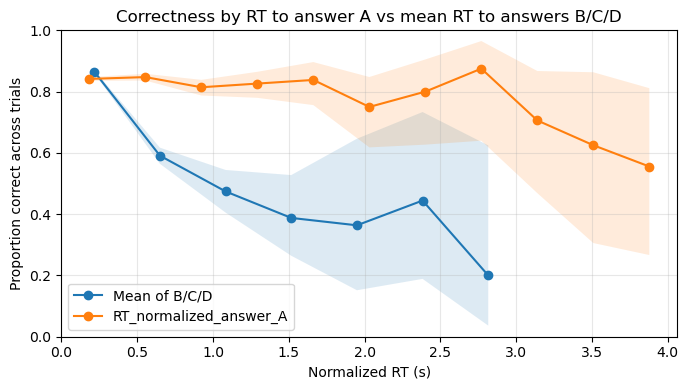

In [50]:
fig, rt_correct_summary = plot_correctness_by_answer_a_vs_bcd_mean(
    all_participants,
    answer_a_col = "RT_normalized_answer_A",
    answer_b_cols = (
        "RT_normalized_answer_B",
        "RT_normalized_answer_C",
        "RT_normalized_answer_D",
    ),
    n_bins=15,
    min_n_per_bin=5,
    title="Correctness by RT to answer A vs mean RT to answers B/C/D",
    x_label="Normalized RT (s)",
    y_label="Proportion correct across trials"
)

display(rt_correct_summary)

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict

from derived.correctness_measures import wilson_ci


def plot_correctness_by_each_answer_rt(
    all_participants: pd.DataFrame,
    answer_cols: Dict[str, str] = None,
    correct_col: str = "is_correct",
    participant_col: str = "participant_id",
    trial_col: str = "TRIAL_INDEX",
    n_bins: int = 10,
    min_n_per_bin: int = 5,
    rt_divisor: float = 1000.0,
    figsize: Tuple[int, int] = (7, 4),
    title: Optional[str] = "Correctness by normalized RT to each answer option",
    x_label: Optional[str] = "Normalized RT (s)",
    y_label: Optional[str] = "Proportion correct across trials",
    show_ci: bool = True,
) -> Tuple[plt.Figure, pd.DataFrame]:
    """
    Plot correctness rate as a function of normalized RT to each answer option.

    Creates four lines:
    - RT_normalized_answer_A
    - RT_normalized_answer_B
    - RT_normalized_answer_C
    - RT_normalized_answer_D

    Deduplicates to one row per participant-trial pair.
    Converts RT columns from ms to seconds by default.
    Uses shared bin edges across all answer columns.
    """

    if answer_cols is None:
        answer_cols = {
            "Answer A (correct)": "RT_normalized_answer_A",
            "Answer B": "RT_normalized_answer_B",
            "Answer C": "RT_normalized_answer_C",
            "Answer D": "RT_normalized_answer_D",
        }

    colors = {
        "Answer A (correct)": "green",
        "Answer B": "gold",
        "Answer C": "orange",
        "Answer D": "red",
}

    rt_cols = list(answer_cols.values())

    required_cols = [
        participant_col,
        trial_col,
        correct_col,
        *rt_cols,
    ]

    missing_cols = [col for col in required_cols if col not in all_participants.columns]
    if missing_cols:
        raise ValueError(f"Missing required column(s): {missing_cols}")

    def _make_binned_summary(
        d: pd.DataFrame,
        x_col: str,
        label: str,
        edges: np.ndarray,
    ) -> pd.DataFrame:
        x = d[x_col].dropna().to_numpy()

        if len(x) == 0:
            return pd.DataFrame()

        bin_idx = np.digitize(d[x_col].to_numpy(), edges, right=False) - 1
        bin_idx[bin_idx == len(edges) - 1] = len(edges) - 2

        valid = (bin_idx >= 0) & (bin_idx < len(edges) - 1)

        tmp = d.loc[valid].copy()
        tmp["_bin"] = bin_idx[valid]

        summary = (
            tmp.groupby("_bin", as_index=False)
            .agg(
                n=(correct_col, "size"),
                k_correct=(correct_col, "sum"),
            )
            .sort_values("_bin")
            .reset_index(drop=True)
        )

        if summary.empty:
            return summary

        summary["bin_left"] = summary["_bin"].apply(lambda i: float(edges[int(i)]))
        summary["bin_right"] = summary["_bin"].apply(lambda i: float(edges[int(i) + 1]))
        summary["bin_center"] = (summary["bin_left"] + summary["bin_right"]) / 2
        summary["accuracy"] = summary["k_correct"] / summary["n"]

        if min_n_per_bin is not None and min_n_per_bin > 1:
            summary = summary[summary["n"] >= int(min_n_per_bin)].copy()

        if summary.empty:
            return summary

        cis = summary.apply(
            lambda r: wilson_ci(int(r["k_correct"]), int(r["n"])),
            axis=1,
        )

        summary["ci_low"] = [c[0] for c in cis]
        summary["ci_high"] = [c[1] for c in cis]
        summary["metric"] = label

        return summary

    # Deduplicate participant-trial pairs
    d = (
        all_participants[required_cols]
        .drop_duplicates(subset=[participant_col, trial_col])
        .copy()
    )

    # Convert to numeric
    numeric_cols = [correct_col, *rt_cols]
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # Convert RT columns from ms to seconds
    d[rt_cols] = d[rt_cols] / rt_divisor

    d = d.dropna(subset=[correct_col, *rt_cols]).copy()
    d[correct_col] = d[correct_col].astype(int)

    # Shared bin edges across all four answer RT columns
    all_x = pd.concat([d[col] for col in rt_cols], ignore_index=True).dropna()

    if all_x.empty:
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_title(title)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_ylim(0, 1)
        fig.tight_layout()
        return fig, pd.DataFrame()

    xmin = float(all_x.min())
    xmax = float(all_x.max())

    if xmin == xmax:
        edges = np.array([xmin - 0.5, xmax + 0.5])
    else:
        edges = np.linspace(xmin, xmax, n_bins + 1)

    summaries = []

    for label, col in answer_cols.items():
        summary_one = _make_binned_summary(
            d=d,
            x_col=col,
            label=label,
            edges=edges,
        )
        summaries.append(summary_one)

    summary = pd.concat(summaries, ignore_index=True)

    fig, ax = plt.subplots(figsize=figsize)

    for metric, group in summary.groupby("metric"):
        color = colors.get(metric)

        ax.plot(
            group["bin_center"],
            group["accuracy"],
            marker="o",
            label=metric,
            color=color,
        )

        if show_ci and len(group) > 0 and group["ci_low"].notna().any():
            ax.fill_between(
                group["bin_center"].to_numpy(),
                group["ci_low"].to_numpy(),
                group["ci_high"].to_numpy(),
                alpha=0.12,
                color=color,
            )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    return fig, summary[
        [
            "metric",
            "bin_left",
            "bin_right",
            "bin_center",
            "n",
            "k_correct",
            "accuracy",
            "ci_low",
            "ci_high",
        ]
    ]

,metric,bin_left,bin_right,bin_center,n,k_correct,accuracy,ci_low,ci_high
0,Answer A (correct),0.00000,0.32035,0.160175,12393,10387,0.838134,0.831545,0.844514
1,Answer A (correct),0.32035,0.64070,0.480525,5138,4407,0.857727,0.847907,0.867012
2,Answer A (correct),0.64070,0.96105,0.800875,1113,900,0.808625,0.784468,0.830660
3,Answer A (correct),0.96105,1.28140,1.121225,426,353,0.828638,0.789957,0.861446
4,Answer A (correct),1.28140,1.60175,1.441575,161,132,0.819876,0.753284,0.871558
5,Answer A (correct),1.60175,1.92210,1.761925,83,68,0.819277,0.722999,0.887307
6,Answer A (correct),1.92210,2.24245,2.082275,36,25,0.694444,0.531434,0.819957
7,Answer A (correct),2.24245,2.56280,2.402625,22,17,0.772727,0.565596,0.898771
8,Answer A (correct),2.56280,2.88315,2.722975,18,16,0.888889,0.671998,0.968981
9,Answer A (correct),2.88315,3.20350,3.043325,12,8,0.666667,0.390618,0.861882


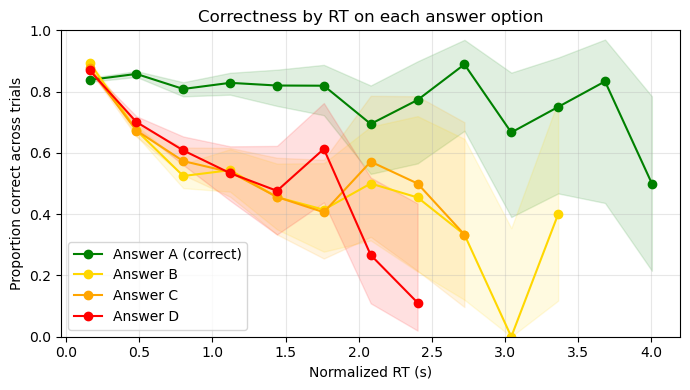

In [67]:
cols = { "Answer A": "RT_pure_answer_A",
                    "Answer B": "RT_pure_answer_B",
                    "Answer C": "RT_pure_answer_C",
                    "Answer D": "RT_pure_answer_D"}

fig, answer_rt_summary = plot_correctness_by_each_answer_rt(
    all_participants,
    #answer_cols = cols,
    n_bins=30,
    min_n_per_bin=5,
    title="Correctness by RT on each answer option",
    x_label="Normalized RT (s)",
    y_label="Proportion correct across trials",
)

display(answer_rt_summary)

In [9]:
import pandas as pd

selected_answer_lookup = (
    all_participants[['participant_id', 'TRIAL_INDEX', 'selected_answer_label']]
    .drop_duplicates(subset=['participant_id', 'TRIAL_INDEX'])
    .copy()
)

trial_pair_df = (
    trial_df
    .drop_duplicates(subset=['participant_id', 'TRIAL_INDEX'])
    .merge(
        selected_answer_lookup,
        on=['participant_id', 'TRIAL_INDEX'],
        how='left'
    )
    .copy()
)

cols_to_numeric = [
    'is_correct',
    'last_before_confirm_answer_A',
    'last_before_confirm_answer_B',
    'last_before_confirm_answer_C',
    'last_before_confirm_answer_D',
]

for col in cols_to_numeric:
    trial_pair_df[col] = pd.to_numeric(trial_pair_df[col], errors='coerce')

matched_sets = []

for text_id, group in trial_pair_df.groupby('text_id_with_q'):
    
    a_candidates = group[
        group['last_before_confirm_answer_A'].eq(1)
        & group['is_correct'].eq(1)
    ]

    b_candidates = group[
        group['last_before_confirm_answer_B'].eq(1)
        & group['is_correct'].eq(0)
    ]

    c_candidates = group[
        group['last_before_confirm_answer_C'].eq(1)
        & group['is_correct'].eq(0)
    ]

    d_candidates = group[
        group['last_before_confirm_answer_D'].eq(1)
        & group['is_correct'].eq(0)
    ]

    if (
        len(a_candidates) > 0
        and len(b_candidates) > 0
        and len(c_candidates) > 0
        and len(d_candidates) > 0
    ):
        a_row = a_candidates.iloc[0]
        b_row = b_candidates.iloc[0]
        c_row = c_candidates.iloc[0]
        d_row = d_candidates.iloc[0]

        matched_sets.append({
            'text_id_with_q': text_id,

            'A_participant_id': a_row['participant_id'],
            'A_TRIAL_INDEX': a_row['TRIAL_INDEX'],
            'A_is_correct': a_row['is_correct'],
            'A_selected_answer_label': a_row['selected_answer_label'],

            'B_participant_id': b_row['participant_id'],
            'B_TRIAL_INDEX': b_row['TRIAL_INDEX'],
            'B_is_correct': b_row['is_correct'],
            'B_selected_answer_label': b_row['selected_answer_label'],

            'C_participant_id': c_row['participant_id'],
            'C_TRIAL_INDEX': c_row['TRIAL_INDEX'],
            'C_is_correct': c_row['is_correct'],
            'C_selected_answer_label': c_row['selected_answer_label'],

            'D_participant_id': d_row['participant_id'],
            'D_TRIAL_INDEX': d_row['TRIAL_INDEX'],
            'D_is_correct': d_row['is_correct'],
            'D_selected_answer_label': d_row['selected_answer_label'],
        })

matched_sets_df = pd.DataFrame(matched_sets)

display(matched_sets_df.head(20))

,text_id_with_q,A_participant_id,A_TRIAL_INDEX,A_is_correct,A_selected_answer_label,B_participant_id,B_TRIAL_INDEX,B_is_correct,B_selected_answer_label,C_participant_id,C_TRIAL_INDEX,C_is_correct,C_selected_answer_label,D_participant_id,D_TRIAL_INDEX,D_is_correct,D_selected_answer_label
0,1_10_Adv_5_1,l39_122,39,1,A,l39_125,45,0,B,l3_66,58,0,C,l57_288,45,0,D
1,1_10_Ele_5_1,l4_68,54,1,A,l40_127,28,0,B,l34_116,56,0,B,l22_53,40,0,C
2,1_10_Ele_6_0,l7_71,56,1,A,l49_154,44,0,B,l37_87,60,0,B,l1_168,8,0,D
3,1_1_Adv_5_2,l39_122,46,1,A,l57_288,24,0,B,l21_52,20,0,B,l15_45,39,0,B
4,1_1_Ele_7_0,l44_540,30,1,A,l50_145,53,0,B,l20_51,36,0,B,l8_268,18,0,D
5,1_2_Adv_2_2,l49_154,13,1,A,l7_71,29,0,B,l25_56,26,0,C,l37_87,35,0,B
6,1_2_Adv_5_1,l14_43,66,1,A,l32_63,18,0,B,l8_76,50,0,C,l2_65,25,0,C
7,1_2_Adv_6_1,l39_122,54,1,A,l27_58,38,0,B,l45_139,24,0,C,l3_265,59,0,D
8,1_2_Ele_1_1,l50_156,20,1,A,l56_489,48,0,D,l32_63,14,0,C,l44_540,17,0,D
9,1_3_Adv_2_2,l34_512,31,1,A,l22_53,27,0,B,l58_177,15,0,C,l40_123,48,0,D


In [9]:
all_participants[(all_participants['participant_id'] == 'l39_122') & (all_participants['TRIAL_INDEX'] == 39)]

,index,TRIAL_INDEX,participant_id,EYE_REPORTED,EYE_TRACKED,IA_AREA,IA_AVERAGE_FIX_PUPIL_SIZE,IA_BOTTOM,IA_DWELL_TIME,IA_DWELL_TIME_%,...,TFD_pure_outside,TFD_normalized_outside,RT_pure_distractor,RT_normalized_distractor,TFD_pure_distractor,TFD_normalized_distractor,RT_pure_critical,RT_normalized_critical,TFD_pure_critical,TFD_normalized_critical
252495,252495,39,l39_122,RIGHT,Right,10260.0,NaN,261,0,0.0000,...,12295.0,183.507463,1583.0,226.142857,1337.0,191.0,28512.0,633.6,13012.0,289.155556
252496,252496,39,l39_122,RIGHT,Right,24624.0,NaN,261,0,0.0000,...,12295.0,183.507463,1583.0,226.142857,1337.0,191.0,28512.0,633.6,13012.0,289.155556
252497,252497,39,l39_122,RIGHT,Right,10260.0,NaN,261,0,0.0000,...,12295.0,183.507463,1583.0,226.142857,1337.0,191.0,28512.0,633.6,13012.0,289.155556
252498,252498,39,l39_122,RIGHT,Right,8208.0,NaN,261,0,0.0000,...,12295.0,183.507463,1583.0,226.142857,1337.0,191.0,28512.0,633.6,13012.0,289.155556
252499,252499,39,l39_122,RIGHT,Right,16416.0,NaN,261,0,0.0000,...,12295.0,183.507463,1583.0,226.142857,1337.0,191.0,28512.0,633.6,13012.0,289.155556
252500,252500,39,l39_122,RIGHT,Right,10260.0,NaN,261,0,0.0000,...,12295.0,183.507463,1583.0,226.142857,1337.0,191.0,28512.0,633.6,13012.0,289.155556
252501,252501,39,l39_122,RIGHT,Right,16416.0,NaN,261,0,0.0000,...,12295.0,183.507463,1583.0,226.142857,1337.0,191.0,28512.0,633.6,13012.0,289.155556
252502,252502,39,l39_122,RIGHT,Right,8208.0,NaN,261,0,0.0000,...,12295.0,183.507463,1583.0,226.142857,1337.0,191.0,28512.0,633.6,13012.0,289.155556
252503,252503,39,l39_122,RIGHT,Right,20628.0,2.413756,261,168,0.0309,...,12295.0,183.507463,1583.0,226.142857,1337.0,191.0,28512.0,633.6,13012.0,289.155556
252504,252504,39,l39_122,RIGHT,Right,12198.0,2.492644,489,255,0.0469,...,12295.0,183.507463,1583.0,226.142857,1337.0,191.0,28512.0,633.6,13012.0,289.155556


In [15]:
ia_rows, fx_rows = save_participant_trial_rows(
    participant_id="l57_288",
    trial_index=45,
    save_location=SAVE_PATH,
    ia_df=ia,
    fx_df=fix,
    name="LAST_D - l57_288_trial45"
)

Saved IA rows: 46 → e:\Technion\QA PROJECT\scanpath examples\scanpath studio data\LAST_D - l57_288_trial45_ia.csv
Saved fixation rows: 29 → e:\Technion\QA PROJECT\scanpath examples\scanpath studio data\LAST_D - l57_288_trial45_fix.csv


## First-4 answer visit heatmap (conference)

Overall heatmap of the first four entries of the simplified fixation sequence,
location-based, questions excluded, across all participants and NOT split by the
answer selected at the end. Cells are row-normalized (share of visits at each
visit-order position). Set `normalize=None`, `fmt="g"` for raw counts.

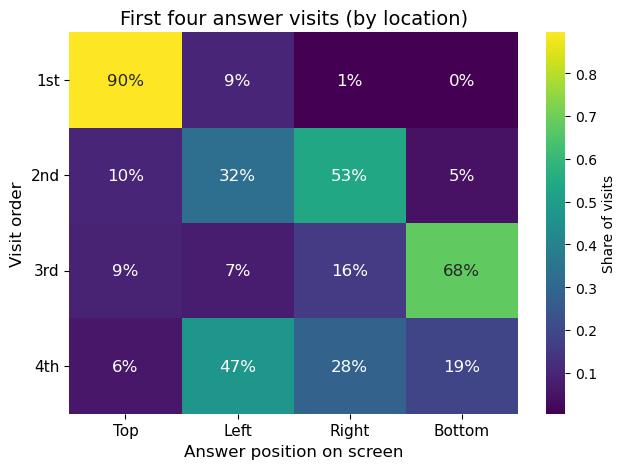

['E:\\Technion\\QA PROJECT\\programming\\QA_eyetracking_workspace\\reports\\plots\\answer_correctness\\first_visits_heatmap\\first4_visits_location_all_participants.png',
 'E:\\Technion\\QA PROJECT\\programming\\QA_eyetracking_workspace\\papers\\correctness_prediction\\figures\\answer_correctness\\first_visits_heatmap\\first4_visits_location_all_participants.png']

In [5]:
from src.viz.visualisations_simplified_visits import matrix_plot_simplified_visits
from viz.plot_output import save_plot

PAPER_DIRS = ["papers/correctness_prediction"]

# Location-based screen positions -> clean labels for the slide.
location_label_map = {
    "answer_0(top)": "Top",
    "answer_1(left)": "Left",
    "answer_2(right)": "Right",
    "answer_3(bottom)": "Bottom",
}

fig, ax, pivot = matrix_plot_simplified_visits(
    all_participants,                 # hunters + gatherers, every trial (no answer split)
    kind="location",
    which="first",
    drop_question=True,               # -> first 4 visits, questions removed
    h_or_g="all participants",
    selected="all",
    figsize=(6.5, 4.8),
    title="First four answer visits (by location)",
    xlabel="Answer position on screen",
    ylabel="Visit order",
    cmap="viridis",
    normalize="row",                  # share of visits per position; use None for raw counts
    fmt=".0%",
    area_label_map=location_label_map,
    position_labels=["1st", "2nd", "3rd", "4th"],
    cbar_label="Share of visits",
    title_fontsize=14,
    label_fontsize=12,
    tick_fontsize=11,
    annot_fontsize=12,
    save=False,
    show=True,
)

save_plot(
    fig=fig,
    rel_dir="answer_correctness/first_visits_heatmap",
    filename="first4_visits_location_all_participants",
    paper_dirs=PAPER_DIRS,
)
